This is a tutorial with examples of peak-fitting to various lineshapes, including multiple peaks, with baseline parameters, making use of parameter bounds.

In [1]:
import sys
sys.path.append('../..')
import pyFidA
import numpy as np
import matplotlib.pyplot as plt

## Sample data
First, create some data that we can use as an example. We will create three Lorentzian peaks of varying height and width, and add noise to them.

<AxesSubplot:xlabel='Chemical Shift (ppm)', ylabel='Signal'>

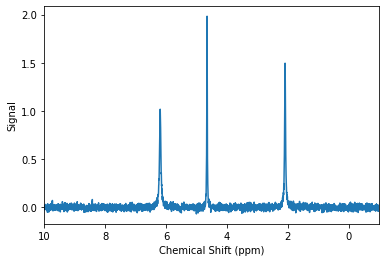

In [2]:
ppmvec=np.linspace(11,-2,4096)
# Parameter order is [amplitudes, FWHM_in_ppm, frequencies_in_ppm]
multi_parvec=[[1.5,2,1],[10/300,5/300,15/300],[2,4.5,6]]
# This the complex y-values for this ppm range with 0.02 complex noise added
SDnoise=0.02
multi_lorentz_peak=pyFidA.op_lorentz(multi_parvec, ppmvec)+SDnoise*np.random.randn(len(ppmvec))+1j*SDnoise*np.random.randn(len(ppmvec))
# Then make this into a FID object
indat=pyFidA.FID(pyFidA.fidA_common.fid_from_specs(multi_lorentz_peak),spectralwidth=4000,txfreq=300e6,dims=['t'])
# Plot our example spectrum
indat.plot_spec(xlims=[10,-1])

## Fitting a single Lorentzian peak
To limit to a single peak, we can select a frequency range (eg. between 1 and 3 ppm to fit the 2 ppm peak). The default initial parameter guess for a Lorentzian will include baseline parameters and phasing, even though these should be zero for our example data.

If you want to exclude the baseline parameters, you can enter an initial parsGuess input argument that does not include them.

[1.493356569071967, 10.350204161700058, 2.0864285272902023, (0.0006530484665645359+0.011624796078537137j), 0.08300096455795856]


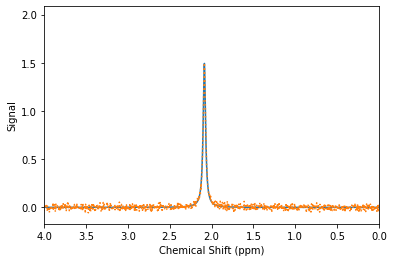

In [3]:
# Default initial parameter guess
outdat,parsFit,resids=pyFidA.op_peakFit(indat,ppmmin=1,ppmmax=3,peaktype='lorentz2')
f1,ax1=plt.subplots(1,1)
outdat.plot_spec(xlims=[4,0],plotax=ax1)
indat.plot_spec(linestyle=':',xlims=[4,0],plotax=ax1)
print(parsFit)

Note that parsFit return the FWHM value (the second parameter) in Hz, even though the lineshape function takes a value in ppm. This is because our FID object was has a transmit frequency of 300 MHz and op_peakFit uses this value to convert between the two. When making an initial guess for op_peakFit, the FWHM should also be entered in Hz. It is only when using the lineshape functions directly (eg. for simulating data) that FWHM values need to be in ppm, because there is no transmit frequency available to these functions.

You can also see that the baseline offset (second-last parameter) is complex and both this and the phase are close to zero (phase is in degrees).

Area under the fitted curve is: 0.051611128606485826
[1.4933695125681363, 10.368055897511372, 2.0864563892183265]


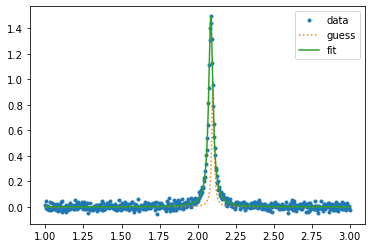

In [5]:
# Use an explicit initial guess in order to avoid fitting the baseline and phase
outdat,parsFit,resids=pyFidA.op_peakFit(indat,ppmmin=1,ppmmax=3,peaktype='lorentz2',parsGuess=[1,5,2.1],show_plot='partial')
print(parsFit)

Here, I've used the input argument show_plot='partial' to plot both the fit and the initial guess in the region that we defined with ppmmin and ppmmax (show_plot=True would plot the entire spectrum, even though we have only fit a portion of it).

The peaktype='lorentz2' corresponds to the op_lorentz function and the help information on this function tells us the parameter order as well as the units.

In [6]:
help(pyFidA.op_lorentz)

Help on function op_lorentz in module pyFidA.fidA_processing.op_peak_fitting:

op_lorentz(pars, ppm)
    yvals=op_lorentz(pars,ppm)
    Wrapper function for op_lorentz_linbas that fixes the baseline slope to 
    zero. This is useful if you want to fit a function with a flat baseline 
    that has an intercept but no slope. All other aspects of 
    op_lorentz_linbas apply: baseline intercept and phase shift are optional 
    parameters; peak amplitudes, fwhm and center frequencies may be supplied as 
    scalars for a single peak or as lists/numpy arrays for multiple peaks.
    
    Parameters
    ----------
    pars : list
        List of parameters to be fitted in the order 
        [amplitude, fwhm (in ppm), center frequency (in ppm), baseline offset, phase shift (in degrees)].
        The baseline offset and phase shift parameters are optional and are 
        scalars. The amplitude, fwhm and center frequency are required and can 
        be scalars (for a single peak) or lists/nu

The implemented peaktype values are available with help(pyFidA.op_peakFit) but it is also possible to enter a function name (a pyFid lineshape function or a user-defined function) directly. However, default initial parameter guess and parameter bounds (covered later) are not implemented in this case. They are only available for the string peaktype options, where they have been hard-coded based on the known function construction.

The code below is equivalent to the above, but uses a callable function instead of a pre-defined string reference for peaktype. Because there is no information about this function hard-coded into op_peakFit, it does not "know" which parameter is the FWHM and now the FWHM should be entered in ppm and will be returned in ppm. Using a value that appears to be in Hz (eg. the 5 Hz value that we used above), throws a warning, and takes more time to find the parameter optimization, although this is successful eventually in this case. The dashed orange line showing the initial guess demonstrates how far off the initial FWHM was.

Area under the fitted curve is: 0.051611128472410624
[1.4933695162550005, 0.03456018614993461, 2.086456389230825]


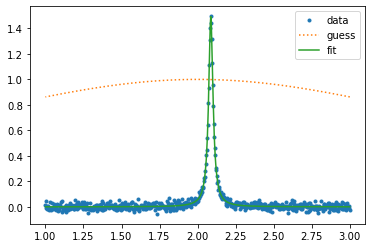

In [7]:
# Use an explicit initial guess in order to avoid fitting the baseline and phase
outdat,parsFit,resids=pyFidA.op_peakFit(indat,ppmmin=1,ppmmax=3,peaktype=pyFidA.op_lorentz,parsGuess=[1,5,2],show_plot='partial')
print(parsFit)

## Fitting multiple peaks
Multiple peaks can be fit with a similar method. The parameters for the function have the same order. But the amplitude, FWHM and center frequency parameters become lists or arrays (either is accepted and the output parameters will have the same type as the inputs). The baseline and phase parameters are scalars, with one value for the entire spectrum, and they remain optional.

One helpful tip, if you do not know the center frequencies exactly, is to use an initial guess with a fairly wide FWHM guess. This helps the function to find the peak and begin converging using the data in this region.

Area under the fitted curve is: [0.05166650196804859, 0.03419538859670215, 0.051554910098934974]
[[1.493501235416312, 1.9928122557929049, 1.0003205651255884], [10.378264324698721, 5.147808856147829, 15.461516606667688], [2.0846839534399475, 4.649857479535314, 6.18880819702166]]


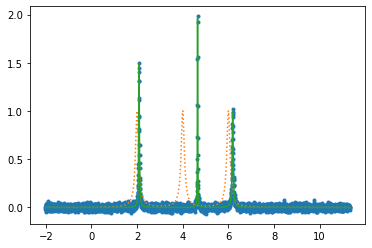

In [10]:
initGuess=[[1,1,1],[50,50,50],[2,4,6]]
outdat,parsFit,resids=pyFidA.op_peakFit(indat,ppmmin=0,ppmmax=8,peaktype='lorentz2',parsGuess=initGuess,show_plot=True)
print(parsFit)

## Fitting the baseline
We can add a baseline to our data. In general, a DC offset can be complex. However, the baseline offset will only be a complex value if we use a complex value\* in our parsGuess (the default values when no initial parsGuess is entered in op_peakFit have the baseline offset and (where available) baseline slope as complex parameters).
(Notes about complex parameter entries)

\* The actual requirement used by nlinfit, the fitting function called in op_peakFit, to determine whether a parameter is expected to be complex is np.iscomplexobj. This is noted because np.iscomplex(aval) will return Fals if aval=0+0j. Whereas np.iscomplexobj(aval) will return True. np.iscomplexobj is applied to the entire list of (for example) amplitude values in the multipeak case, meaning that, if any of these values are complex, then the fit will assume that all amplitude values should be fit as complex numbers. Of course, the amplitudes ought to be real numbers in any normal spectroscopic fit. It is anticipated that complex values might only be needed for the baseline slope and offset. But the function is set up to handle other cases for users who write their own functions that might have complex fit parameters.

In [11]:
np.iscomplex(0j)

False

## Parameter bounds
In some cases the fit may fail. It may be helpful to add parameter bounds. In particular, some of the FWHM values are very high. For the peaktype values that are strings, we can set paramet

Area under the fitted curve is: [0.05131687333479733, 1.181961724041016e-05, 0.0007224348245552307]
[[1.4958711049479028, 0.03545885158819077, 0.044564116123712735], [10.291703576275287, 0.10000000037519463, 4.863339974362156], [2.085321689165293, 4.023484440399141, 5.000000000000144]]


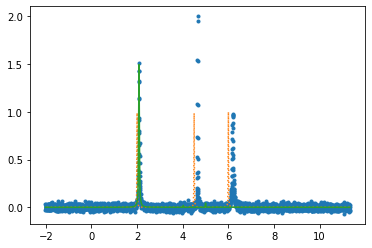

In [28]:
initGuess=[[1,1,1],[5,5,5],[2,4.5,6]]
lbs=[[0,0,0],[0.1,0.1,0.1],[1,3,5]]
ubs=[[10,10,10],[50,50,50],[3,5,7]]
outdat,parsFit,resids=pyFidA.op_peakFit(indat,peaktype='lorentz2',parsGuess=initGuess,show_plot=True,parameter_bounds=[lbs,ubs])
print(parsFit)

## Other lineshapes

## A note about complex data
Show what happens if you send just the real part of the spectrum in.